# Entregável 9: Seleção de Atributos
**Disciplina:** Aquisição de Biossinais
**Equipe:** José Ferreira Lessa e Matheus Rocha Gomes da Silva
**Objetivo:** Identificar o subconjunto mínimo de features originais interpretáveis com máximo poder discriminativo para a tarefa de classificação multi-label das superclasses diagnósticas. Diferente do PCA (Entregável 8), que cria componentes sintéticos, aqui mantemos as features originais com significado fisiológico direto, aplicando métodos Filter, Wrapper e Embedded.

## 1. Instalação de Dependências e Importações

In [15]:
# Instalar pacotes adicionais necessários para este entregável
# Descomente a linha abaixo para instalar caso não tenha os pacotes
# %pip install skrebate mlxtend statsmodels

import os
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from mlxtend.feature_selection import SequentialFeatureSelector as SFS_mlx
from skrebate import ReliefF
from IPython.display import display, Markdown
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 2. Carregamento do Dataset Engenhado

In [16]:
DIR_IN_D7 = '../../entregavel-7/outputs/'
DIR_OUT_D9 = '../outputs/'
FIGS_DIR = '../figuras/'
os.makedirs(DIR_OUT_D9, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

print("Carregando features do Entregável 7...")
df = pd.read_parquet(os.path.join(DIR_IN_D7, 'features_engineered.parquet'))

# Converter superclasses de string para lista, se necessário
if isinstance(df['diagnostic_superclass'].iloc[0], str):
    df['diagnostic_superclass'] = df['diagnostic_superclass'].apply(ast.literal_eval)

meta_cols = ['patient_id', 'strat_fold', 'sqi_category', 'diagnostic_superclass', 'label_primary']
feature_cols = [c for c in df.columns if c not in meta_cols]

# Máscaras de split
mask_train = df['strat_fold'].isin(range(1, 9))  # Folds 1-8
mask_val   = df['strat_fold'] == 9
mask_test  = df['strat_fold'] == 10

superclasses = ['NORM', 'MI', 'CD', 'STTC', 'HYP']

# Criar labels binários one-vs-rest para cada superclasse
for sc in superclasses:
    df[f'label_{sc}'] = df['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

X_train = df.loc[mask_train, feature_cols].values
y_train_dict = {sc: df.loc[mask_train, f'label_{sc}'].values for sc in superclasses}

print(f"Dataset: {df.shape[0]} amostras, {len(feature_cols)} features")
print(f"Treino: {mask_train.sum()} | Val: {mask_val.sum()} | Teste: {mask_test.sum()}")
for sc in superclasses:
    pos = y_train_dict[sc].sum()
    print(f"  {sc}: {pos} positivos ({100*pos/len(y_train_dict[sc]):.1f}%)")

Carregando features do Entregável 7...
Dataset: 21735 amostras, 213 features
Treino: 17372 | Val: 2178 | Teste: 2185
  NORM: 7520 positivos (43.3%)
  MI: 3296 positivos (19.0%)
  CD: 3890 positivos (22.4%)
  STTC: 4052 positivos (23.3%)
  HYP: 1819 positivos (10.5%)


---
## Seção 1 — Definição da Tarefa de Seleção

### 1.1 Multi-Label vs. Multi-Classe

No PTB-XL, um mesmo registro pode pertencer a múltiplas superclasses diagnósticas simultaneamente. Isso torna a seleção de features mais complexa: uma feature pode ser altamente discriminativa para MI vs. Rest, mas irrelevante para CD vs. Rest.

**Estratégia adotada:** Realizar a seleção separadamente para cada superclasse como problema binário *one-vs-rest*, depois unir os conjuntos. Uma feature é incluída no conjunto final se for selecionada por **ao menos 2 dos 5** classificadores binários — garantindo relevância transversal sem exigir universalidade.

---
## Seção 2 — Métodos Filter

Os métodos Filter avaliam a relevância de cada feature independentemente do modelo de classificação, usando apenas propriedades estatísticas dos dados. Vantagem: rápidos e agnósticos ao modelo. Desvantagem: ignoram interações entre features.

### 2.1 ANOVA F-statistic
Reutilizamos a ANOVA do Entregável 7, agora com seleção formal: Top-50 features por superclasse com p < 0.05 (correção de Bonferroni).

In [17]:
print("=== ANOVA F-statistic (Filter 1/3) ===")
N_TOP = 50
n_tests = len(feature_cols)

anova_results = {}
anova_selected = {}

for sc in tqdm(superclasses, desc="ANOVA"):
    F_vals, p_vals = f_classif(X_train, y_train_dict[sc])
    # Correção de Bonferroni
    p_corrected = np.minimum(p_vals * n_tests, 1.0)
    
    df_anova = pd.DataFrame({
        'feature': feature_cols,
        'F': F_vals,
        'p_raw': p_vals,
        'p_bonferroni': p_corrected
    }).sort_values('F', ascending=False)
    
    anova_results[sc] = df_anova
    # Selecionar top-N com p corrigido significativo
    sig_mask = df_anova['p_bonferroni'] < 0.05
    selected = df_anova[sig_mask].head(N_TOP)['feature'].tolist()
    anova_selected[sc] = selected
    print(f"  {sc}: {len(selected)} features selecionadas (p_bonf < 0.05, top-{N_TOP})")

# União de todas as superclasses
anova_union = list(set().union(*anova_selected.values()))
print(f"\nUnião ANOVA: {len(anova_union)} features únicas")

=== ANOVA F-statistic (Filter 1/3) ===


ANOVA:   0%|          | 0/5 [00:00<?, ?it/s]

  NORM: 50 features selecionadas (p_bonf < 0.05, top-50)
  MI: 50 features selecionadas (p_bonf < 0.05, top-50)
  CD: 50 features selecionadas (p_bonf < 0.05, top-50)
  STTC: 50 features selecionadas (p_bonf < 0.05, top-50)
  HYP: 50 features selecionadas (p_bonf < 0.05, top-50)

União ANOVA: 139 features únicas


### 2.2 Mutual Information
A MI captura dependências não-lineares entre feature e label, sem assumir relação funcional específica.

In [18]:
print("=== Mutual Information (Filter 2/3) ===")
mi_results = {}
mi_selected = {}

for sc in tqdm(superclasses, desc="Mut. Info"):
    mi_scores = mutual_info_classif(X_train, y_train_dict[sc], random_state=42, n_neighbors=5)
    
    df_mi = pd.DataFrame({
        'feature': feature_cols,
        'MI': mi_scores
    }).sort_values('MI', ascending=False)
    
    mi_results[sc] = df_mi
    selected = df_mi.head(N_TOP)['feature'].tolist()
    mi_selected[sc] = selected
    print(f"  {sc}: top-{N_TOP} features selecionadas (MI)")

mi_union = list(set().union(*mi_selected.values()))
print(f"\nUnião MI: {len(mi_union)} features únicas")

# Comparação ANOVA vs MI
overlap = set(anova_union) & set(mi_union)
print(f"Overlap ANOVA ∩ MI: {len(overlap)} features em comum (robustez metodológica)")

=== Mutual Information (Filter 2/3) ===


Mut. Info:   0%|          | 0/5 [00:00<?, ?it/s]

  NORM: top-50 features selecionadas (MI)
  MI: top-50 features selecionadas (MI)
  CD: top-50 features selecionadas (MI)
  STTC: top-50 features selecionadas (MI)
  HYP: top-50 features selecionadas (MI)

União MI: 140 features únicas
Overlap ANOVA ∩ MI: 120 features em comum (robustez metodológica)


### 2.3 ReliefF
O ReliefF avalia a utilidade de cada feature com base na capacidade de distinguir entre vizinhos de classes diferentes (*near-misses*) vs. vizinhos da mesma classe (*near-hits*). Computacionalmente pesado: usamos subset estratificado de 5.000 amostras.

In [19]:
print("=== ReliefF (Filter 3/3) ===")
# Subset estratificado para viabilidade computacional
from sklearn.utils import resample

n_relief_samples = min(5000, X_train.shape[0])
# Usar label_primary para estratificação
y_primary_train = df.loc[mask_train, 'label_primary'].values

# Amostragem estratificada simples
np.random.seed(42)
idx_all = np.arange(X_train.shape[0])
# Selecionar proporcionalmente
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, train_size=n_relief_samples, random_state=42)
idx_subset, _ = next(sss.split(X_train, y_primary_train))

X_relief = X_train[idx_subset]
y_relief = y_primary_train[idx_subset]

# Label encoding para ReliefF
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_relief_enc = le.fit_transform(y_relief)

print(f"Executando ReliefF com {n_relief_samples} amostras e k=10 vizinhos...")
relief = ReliefF(n_neighbors=10, n_features_to_select=N_TOP)
relief.fit(X_relief, y_relief_enc)

relief_scores = relief.feature_importances_
df_relief = pd.DataFrame({
    'feature': feature_cols,
    'relief_score': relief_scores
}).sort_values('relief_score', ascending=False)

relief_selected = df_relief.head(N_TOP)['feature'].tolist()
print(f"ReliefF: Top-{N_TOP} features selecionadas")
print(f"Top 10: {relief_selected[:10]}")

=== ReliefF (Filter 3/3) ===
Executando ReliefF com 5000 amostras e k=10 vizinhos...
ReliefF: Top-50 features selecionadas
Top 10: ['morph_qrs_width_V5_median', 'morph_t_amp_II_median', 'morph_t_amp_V5_median', 'morph_qrs_width_II_median', 'time_kurt_aVL', 'time_skew_II', 'time_kurt_I', 'morph_st_amp_V5_median', 'morph_st_amp_II_median', 'time_skew_aVL']


### 2.4 Síntese Filter: Ranking Unificado
Criamos um score de consenso normalizado combinando os três métodos Filter. Features com score > 0.7 formam o conjunto **Filter Top**.

Conjunto Filter Top (score > 0.7): 50 features


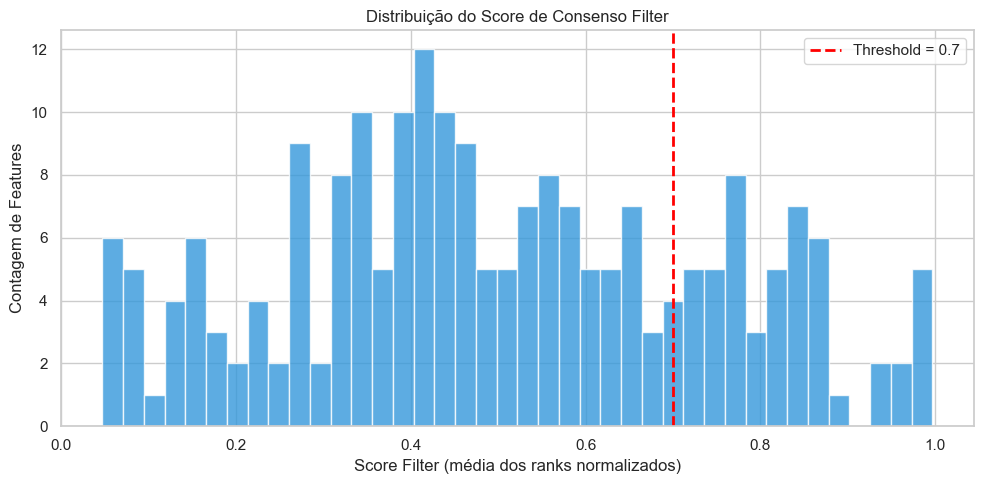

,feature,rank_anova,rank_mi,rank_relief,score_filter
171,morph_qrs_width_V5_median,0.995283,0.995283,1.000000,0.996855
175,morph_t_amp_V5_median,0.966981,1.000000,0.990566,0.985849
167,morph_t_amp_II_median,0.971698,0.990566,0.995283,0.985849
13,time_skew_II,1.000000,0.976415,0.976415,0.984277
173,morph_st_amp_V5_median,0.976415,0.981132,0.966981,0.974843
27,time_skew_aVL,0.990566,0.952830,0.957547,0.966981
163,morph_qrs_width_II_median,0.886792,0.985849,0.985849,0.952830
165,morph_st_amp_II_median,0.938679,0.924528,0.962264,0.941824
28,time_kurt_aVL,0.915094,0.882075,0.981132,0.926101
84,time_kurt_V6,0.900943,0.849057,0.900943,0.883648


In [20]:
# Criar rankings normalizados (0 a 1, onde 1 = mais relevante)
n_feat = len(feature_cols)

# Rank ANOVA: usar max_F entre superclasses
max_F_per_feat = np.zeros(n_feat)
for sc in superclasses:
    df_a = anova_results[sc].set_index('feature')
    for i, feat in enumerate(feature_cols):
        if feat in df_a.index:
            max_F_per_feat[i] = max(max_F_per_feat[i], df_a.loc[feat, 'F'])

rank_anova = np.zeros(n_feat)
order = max_F_per_feat.argsort()
rank_anova[order] = np.linspace(0, 1, n_feat)

# Rank MI: usar max MI entre superclasses
max_MI_per_feat = np.zeros(n_feat)
for sc in superclasses:
    df_m = mi_results[sc].set_index('feature')
    for i, feat in enumerate(feature_cols):
        if feat in df_m.index:
            max_MI_per_feat[i] = max(max_MI_per_feat[i], df_m.loc[feat, 'MI'])

rank_mi = np.zeros(n_feat)
order = max_MI_per_feat.argsort()
rank_mi[order] = np.linspace(0, 1, n_feat)

# Rank ReliefF
rank_relief = np.zeros(n_feat)
order = relief_scores.argsort()
rank_relief[order] = np.linspace(0, 1, n_feat)

# Score de consenso
score_filter = (rank_anova + rank_mi + rank_relief) / 3.0

df_consensus = pd.DataFrame({
    'feature': feature_cols,
    'rank_anova': rank_anova,
    'rank_mi': rank_mi,
    'rank_relief': rank_relief,
    'score_filter': score_filter
}).sort_values('score_filter', ascending=False)

# Filter Top: score > 0.7
filter_top_mask = df_consensus['score_filter'] > 0.7
filter_top_features = df_consensus[filter_top_mask]['feature'].tolist()
print(f"Conjunto Filter Top (score > 0.7): {len(filter_top_features)} features")

# Histograma do score
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(score_filter, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(x=0.7, color='red', linestyle='--', lw=2, label='Threshold = 0.7')
ax.set_title('Distribuição do Score de Consenso Filter')
ax.set_xlabel('Score Filter (média dos ranks normalizados)')
ax.set_ylabel('Contagem de Features')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'filter_consensus_histogram.png'), dpi=150)
plt.show()

# Top 20
display(df_consensus.head(20)[['feature', 'rank_anova', 'rank_mi', 'rank_relief', 'score_filter']])

---
## Seção 3 — Métodos Wrapper

Os Wrappers avaliam subconjuntos de features treinando um classificador proxy e medindo a performance preditiva. São mais precisos que Filters por capturar interações, mas muito mais custosos computacionalmente.

Para viabilidade, aplicaremos SFS e SBE **apenas sobre o conjunto Filter Top** (em vez de todas as features).

### 3.1 Sequential Forward Selection (SFS)
Adiciona features uma a uma, escolhendo em cada passo aquela que mais melhora a balanced accuracy.

=== Sequential Forward Selection (SFS) ===
Partindo do Filter Top com 50 features...
Executando SFS (1 a 30 features)... Pode levar alguns minutos.


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   12.3s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:   15.5s finished

[2026-04-01 20:00:44] Features: 1/30 -- score: 0.3062082682948356[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   12.5s
[Parallel(n_jobs=1)]: Done  49 out of  49 | elapsed:   15.4s finished

[2026-04-01 20:01:00] Features: 2/30 -- score: 0.3566318547926421[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   15.5s
[Parallel(n_jobs=1)]: Done  48 out of  48 | elapsed:   18.6s finished

[2026-04-01 20:01:18] Features: 3/30 -- score: 0.37682380096062246[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   18.1s
[Parallel(n_jobs=1)]: Done  47 out of  47 | elapsed:   21.4s finished

[2026-04-01 20:01:40] Features: 4/30 -- score: 0.39282855854991383[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   21.0s
[Parallel(n_jobs=1)]: Done  46 out of  46 | elapsed:   24.2s finished

[2026-04-01 20:02:04] Features: 5/30 -- score: 0.40413393959939253[Parallel(n_

SFS: Melhor score = 0.4305
SFS: K ótimo (95% do máximo) = 6 features


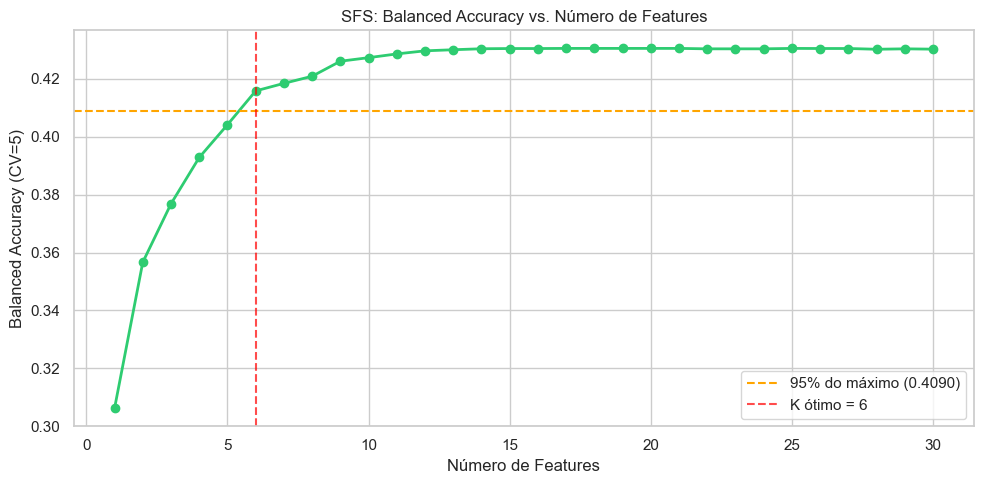

In [24]:
print("=== Sequential Forward Selection (SFS) ===")
print(f"Partindo do Filter Top com {len(filter_top_features)} features...")

# Classificador proxy rápido
clf_proxy = DecisionTreeClassifier(max_depth=5, random_state=42)

# Preparar dados do Filter Top (apenas treino)
X_train_ft = df.loc[mask_train, filter_top_features].values # Passando numpy array para evitar problemas do mlxtend
# Usar label_primary para o wrapper (multi-classe simplificado)
y_train_primary = df.loc[mask_train, 'label_primary'].values

# Limitar k_features para viabilidade (máximo de features do Filter Top ou 30, o que for menor)
max_k = min(len(filter_top_features), 30)

sfs = SFS_mlx(clf_proxy,
              k_features=(1, max_k),
              forward=True,
              floating=False,
              scoring='balanced_accuracy',
              cv=5,
              n_jobs=1,
              verbose=2)

print(f"Executando SFS (1 a {max_k} features)... Pode levar alguns minutos.")
sfs.fit(X_train_ft, y_train_primary)

# Extrair resultados
sfs_results = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sfs_results['n_features'] = sfs_results.index.astype(int)
sfs_results['avg_score'] = sfs_results['avg_score'].astype(float)

# Melhor score e platô
best_score = sfs_results['avg_score'].max()
threshold_95 = 0.95 * best_score
sfs_optimal_k = sfs_results[sfs_results['avg_score'] >= threshold_95]['n_features'].min()

best_idx_sfs = sfs.subsets_[sfs_optimal_k]['feature_idx']
sfs_best_features = [filter_top_features[i] for i in best_idx_sfs]
print(f"SFS: Melhor score = {best_score:.4f}")
print(f"SFS: K ótimo (95% do máximo) = {sfs_optimal_k} features")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sfs_results['n_features'], sfs_results['avg_score'], 'o-', color='#2ecc71', lw=2)
ax.axhline(y=threshold_95, color='orange', linestyle='--', label=f'95% do máximo ({threshold_95:.4f})')
ax.axvline(x=sfs_optimal_k, color='red', linestyle='--', alpha=0.7, label=f'K ótimo = {sfs_optimal_k}')
ax.set_title('SFS: Balanced Accuracy vs. Número de Features')
ax.set_xlabel('Número de Features')
ax.set_ylabel('Balanced Accuracy (CV=5)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'sfs_curve.png'), dpi=150)
plt.show()


### 3.2 Sequential Backward Elimination (SBE)
Remove features uma a uma, partindo do Filter Top, eliminando aquela cuja remoção menos prejudica a performance.

In [25]:
print("=== Sequential Backward Elimination (SBE) ===")

sbe = SFS_mlx(clf_proxy,
              k_features=(1, max_k),
              forward=False,
              floating=False,
              scoring='balanced_accuracy',
              cv=5,
              n_jobs=1,
              verbose=2)

print(f"Executando SBE ({len(filter_top_features)} -> 1 feature)... Pode levar alguns minutos.")
sbe.fit(X_train_ft, y_train_primary)

sbe_results = pd.DataFrame.from_dict(sbe.get_metric_dict()).T
sbe_results['n_features'] = sbe_results.index.astype(int)
sbe_results['avg_score'] = sbe_results['avg_score'].astype(float)

best_score_sbe = sbe_results['avg_score'].max()
threshold_95_sbe = 0.95 * best_score_sbe
sbe_optimal_k = sbe_results[sbe_results['avg_score'] >= threshold_95_sbe]['n_features'].min()

best_idx_sbe = sbe.subsets_[sbe_optimal_k]['feature_idx']
sbe_best_features = [filter_top_features[i] for i in best_idx_sbe]

print(f"SBE: Melhor score = {best_score_sbe:.4f}")
print(f"SBE: K ótimo (95% do máximo) = {sbe_optimal_k} features")

# Comparação SFS vs SBE
overlap_wrapper = set(sfs_best_features) & set(sbe_best_features)
union_wrapper = list(set(sfs_best_features) | set(sbe_best_features))

print(f"\nConvergência SFS ∩ SBE: {len(overlap_wrapper)} features em comum")
print(f"União SFS ∪ SBE: {len(union_wrapper)} features")

if len(overlap_wrapper) / max(len(sfs_best_features), len(sbe_best_features)) > 0.5:
    print("Alta convergência entre métodos -> confiança na seleção")
    wrapper_final = list(overlap_wrapper) if len(overlap_wrapper) >= 5 else union_wrapper
else:
    print("Divergência entre métodos -> usar a união (conservador)")
    wrapper_final = union_wrapper

print(f"Conjunto Wrapper final: {len(wrapper_final)} features")

=== Sequential Backward Elimination (SBE) ===
Executando SBE (50 -> 1 feature)... Pode levar alguns minutos.


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  2.4min
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:  3.0min finished

[2026-04-01 20:23:00] Features: 49/1 -- score: 0.4132432072282043[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  2.3min
[Parallel(n_jobs=1)]: Done  49 out of  49 | elapsed:  2.9min finished

[2026-04-01 20:25:53] Features: 48/1 -- score: 0.4181507151305553[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  2.3min
[Parallel(n_jobs=1)]: Done  48 out of  48 | elapsed:  2.8min finished

[2026-04-01 20:28:39] Features: 47/1 -- score: 0.42037076851682886[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  2.3min
[Parallel(n_jobs=1)]: Done  47 out of  47 | elapsed:  2.7min finished

[2026-04-01 20:31:20] Features: 46/1 -- score: 0.42221838389847166[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  2.2min
[Parallel(n_jobs=1)]: Done  46 out of  46 | elapsed:  2.6min finished

[2026-04-01 20:33:55] Features: 45/1 -- score: 0.42323222358953816[Parallel(n_

SBE: Melhor score = 0.4273
SBE: K ótimo (95% do máximo) = 5 features

Convergência SFS ∩ SBE: 2 features em comum
União SFS ∪ SBE: 9 features
Divergência entre métodos -> usar a união (conservador)
Conjunto Wrapper final: 9 features


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.7s finished

[2026-04-01 21:12:44] Features: 1/1 -- score: 0.273619195585003

---
## Seção 4 — Método Embedded (LASSO / Regularização L1)

O LASSO (L1) força coeficientes irrelevantes a exatamente zero durante o ajuste. Feature sobrevivente = genuinamente informativa sob o modelo linear.

### 4.1 Caminho de Regularização e Seleção por Superclasse

=== LASSO L1 (Embedded) ===


LASSO paths:   0%|          | 0/5 [00:00<?, ?it/s]

  NORM: best C=0.1269, BA_val=0.8565, 128 features não-zero
  MI: best C=0.3290, BA_val=0.7020, 171 features não-zero
  CD: best C=0.3290, BA_val=0.7623, 161 features não-zero
  STTC: best C=0.0788, BA_val=0.7859, 116 features não-zero
  HYP: best C=0.3290, BA_val=0.6518, 153 features não-zero


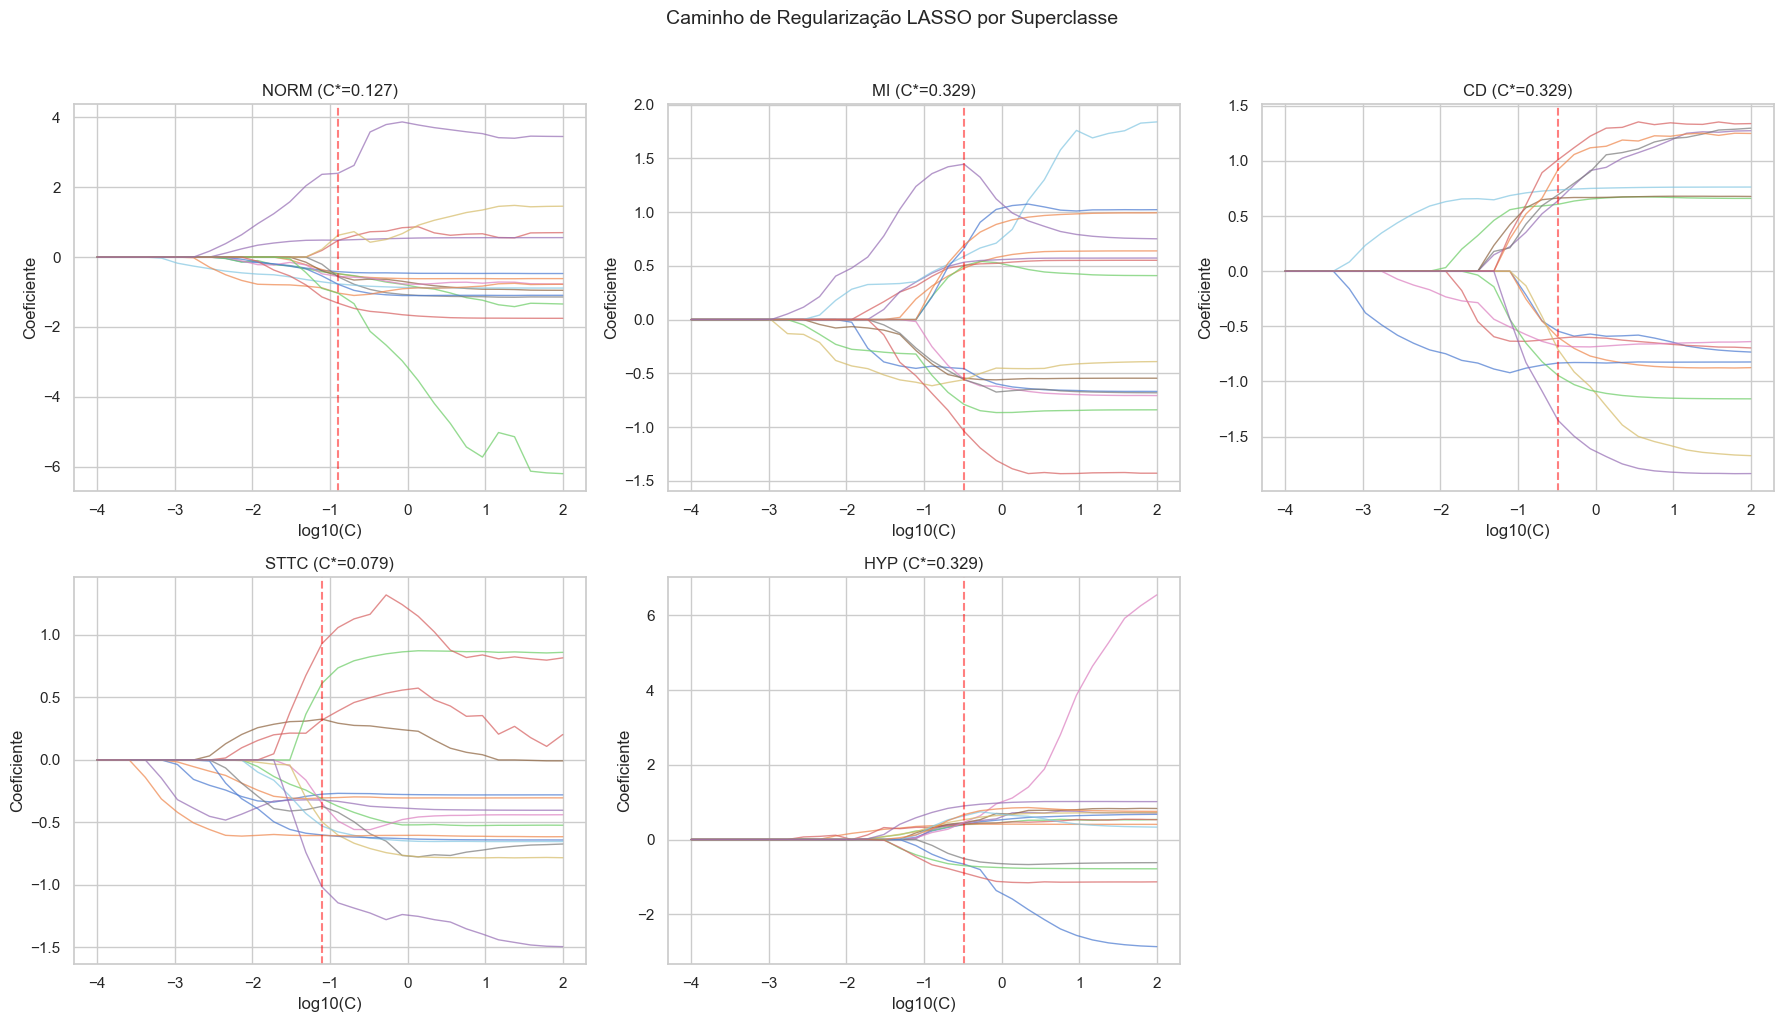


LASSO: 193 features selecionadas em >= 2 superclasses


In [26]:
print("=== LASSO L1 (Embedded) ===")
C_range = np.logspace(-4, 2, 30)  # 30 valores de C

X_train_all = df.loc[mask_train, feature_cols].values
X_val_all = df.loc[mask_val, feature_cols].values

lasso_selected = {}
best_C_per_sc = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx_sc, sc in enumerate(tqdm(superclasses, desc="LASSO paths")):
    y_tr = y_train_dict[sc]
    y_vl = df.loc[mask_val, f'label_{sc}'].values
    
    # Caminho de regularização
    coef_path = []
    scores_path = []
    
    for C in C_range:
        lr = LogisticRegression(penalty='l1', C=C, solver='liblinear',
                                random_state=42, max_iter=1000)
        lr.fit(X_train_all, y_tr)
        coef_path.append(lr.coef_[0].copy())
        
        y_pred = lr.predict(X_val_all)
        scores_path.append(balanced_accuracy_score(y_vl, y_pred))
    
    coef_path = np.array(coef_path)  # shape: (n_C, n_features)
    scores_path = np.array(scores_path)
    
    # Melhor C pela validação
    best_idx = np.argmax(scores_path)
    best_C = C_range[best_idx]
    best_C_per_sc[sc] = best_C
    
    # Features não-zero no melhor C
    nonzero_mask = coef_path[best_idx] != 0
    selected = [feature_cols[i] for i in range(len(feature_cols)) if nonzero_mask[i]]
    lasso_selected[sc] = selected
    
    print(f"  {sc}: best C={best_C:.4f}, BA_val={scores_path[best_idx]:.4f}, {len(selected)} features não-zero")
    
    # Plot do caminho de regularização (top 15 features por magnitude)
    ax = axes[idx_sc]
    top_feat_idx = np.abs(coef_path[best_idx]).argsort()[-15:]
    for fi in top_feat_idx:
        ax.plot(np.log10(C_range), coef_path[:, fi], lw=1, alpha=0.7)
    ax.axvline(x=np.log10(best_C), color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{sc} (C*={best_C:.3f})')
    ax.set_xlabel('log10(C)')
    ax.set_ylabel('Coeficiente')

# Desligar subplot extra
if len(superclasses) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Caminho de Regularização LASSO por Superclasse', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'lasso_regularization_path.png'), dpi=150, bbox_inches='tight')
plt.show()

# Features selecionadas em ao menos 2 superclasses
from collections import Counter
all_lasso = [f for feats in lasso_selected.values() for f in feats]
lasso_counts = Counter(all_lasso)
lasso_final = [f for f, cnt in lasso_counts.items() if cnt >= 2]
print(f"\nLASSO: {len(lasso_final)} features selecionadas em >= 2 superclasses")

---
## Seção 5 — Validação Estatística das Features Candidatas

### 5.1 Definição do Conjunto Candidato
União das features selecionadas por: consenso Filter (score > 0.7), Wrapper (SFS/SBE) e LASSO (coef não-zero em >= 2 superclasses).

In [27]:
# Conjunto candidato = união dos 3 métodos
candidate_features = list(set(filter_top_features) | set(wrapper_final) | set(lasso_final))
print(f"Conjunto candidato (união Filter + Wrapper + Embedded): {len(candidate_features)} features")

# Registrar de onde cada feature veio
source_map = {}
for f in candidate_features:
    sources = []
    if f in filter_top_features: sources.append('Filter')
    if f in wrapper_final: sources.append('Wrapper')
    if f in lasso_final: sources.append('LASSO')
    source_map[f] = sources

Conjunto candidato (união Filter + Wrapper + Embedded): 196 features


### 5.2 Testes de Hipótese Par-a-Par (Mann-Whitney U)
Como confirmado no Entregável 3, as distribuições não são normais. Usamos o teste não-paramétrico de Mann-Whitney U para cada feature em todos os 10 pares de superclasses.

In [28]:
print("=== Testes de Hipótese par-a-par ===")
from itertools import combinations

# Preparar dados de treino com label único (para comparações limpas)
df_train = df[mask_train].copy()

pares = list(combinations(superclasses, 2))
print(f"Número de pares: {len(pares)}")
print(f"Número total de comparações: {len(candidate_features)} x {len(pares)} = {len(candidate_features) * len(pares)}")

# Coletar todos os p-values e U-statistics
all_tests = []

for feat in candidate_features:
    for (c1, c2) in pares:
        group1 = df_train[df_train[f'label_{c1}'] == 1][feat].dropna()
        group2 = df_train[df_train[f'label_{c2}'] == 1][feat].dropna()
        
        if len(group1) < 5 or len(group2) < 5:
            continue
        
        U, p = mannwhitneyu(group1, group2, alternative='two-sided')
        # Rank-Biserial Correlation
        n1, n2 = len(group1), len(group2)
        r_rb = 1 - (2 * U) / (n1 * n2)
        
        all_tests.append({
            'feature': feat,
            'par': f'{c1}_vs_{c2}',
            'U': U,
            'p_raw': p,
            'r_rb': r_rb,
            'abs_r': abs(r_rb),
            'n1': n1,
            'n2': n2
        })

df_tests = pd.DataFrame(all_tests)
print(f"Total de comparações realizadas: {len(df_tests)}")

=== Testes de Hipótese par-a-par ===
Número de pares: 10
Número total de comparações: 196 x 10 = 1960
Total de comparações realizadas: 1960


### 5.3 Correção de Múltiplas Comparações
Aplicamos Bonferroni (conservador) e Benjamini-Hochberg FDR (principal).

In [29]:
# Bonferroni
df_tests['p_bonferroni'] = np.minimum(df_tests['p_raw'] * len(df_tests), 1.0)

# Benjamini-Hochberg (FDR)
reject_fdr, p_fdr, _, _ = multipletests(df_tests['p_raw'], alpha=0.05, method='fdr_bh')
df_tests['p_fdr'] = p_fdr
df_tests['sig_fdr'] = reject_fdr
df_tests['sig_bonf'] = df_tests['p_bonferroni'] < 0.05

n_sig_fdr = df_tests['sig_fdr'].sum()
n_sig_bonf = df_tests['sig_bonf'].sum()
print(f"Comparações significativas (FDR q<0.05): {n_sig_fdr} / {len(df_tests)} ({100*n_sig_fdr/len(df_tests):.1f}%)")
print(f"Comparações significativas (Bonferroni): {n_sig_bonf} / {len(df_tests)} ({100*n_sig_bonf/len(df_tests):.1f}%)")

# Features que sobrevivem
feats_sig_fdr = df_tests[df_tests['sig_fdr']]['feature'].unique()
feats_sig_bonf = df_tests[df_tests['sig_bonf']]['feature'].unique()
print(f"\nFeatures com ao menos 1 comparação significativa (FDR): {len(feats_sig_fdr)}")
print(f"Features com ao menos 1 comparação significativa (Bonferroni): {len(feats_sig_bonf)}")

Comparações significativas (FDR q<0.05): 1766 / 1960 (90.1%)
Comparações significativas (Bonferroni): 1593 / 1960 (81.3%)

Features com ao menos 1 comparação significativa (FDR): 196
Features com ao menos 1 comparação significativa (Bonferroni): 196


### 5.4 Effect Size (Rank-Biserial Correlation)
Descartamos comparações com |r| < 0.1 mesmo que significativas — amostras grandes podem tornar diferenças triviais estatisticamente significativas.

Distribuição dos Effect Sizes (todas as comparações):


,Contagem
effect_cat,
Pequeno,935
Trivial,592
Médio,337
Grande,96



Features com ao menos 1 comparação significativa E |r| >= 0.1: 194


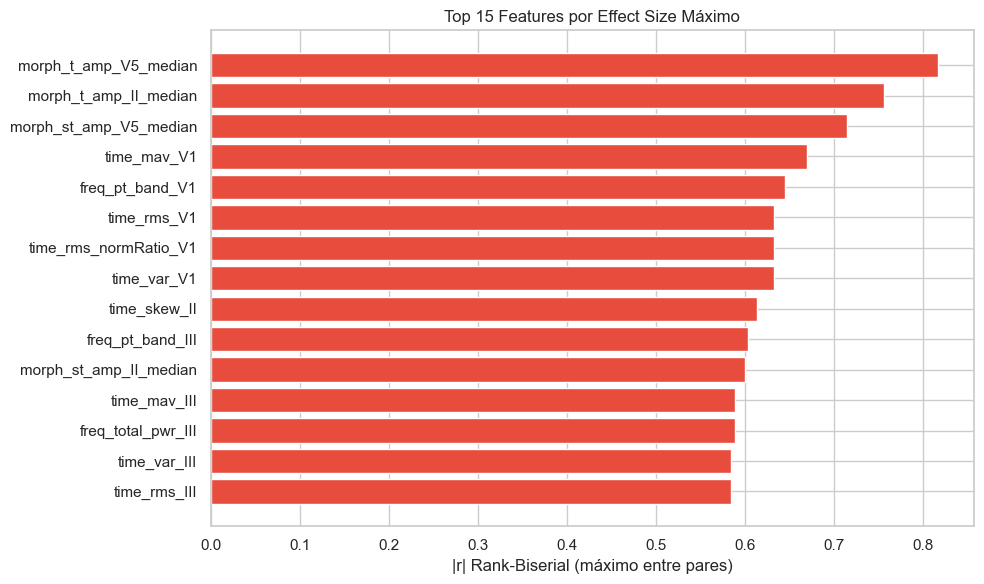

In [30]:
# Filtrar por effect size
df_tests['effect_cat'] = pd.cut(df_tests['abs_r'],
                                 bins=[0, 0.1, 0.3, 0.5, 1.0],
                                 labels=['Trivial', 'Pequeno', 'Médio', 'Grande'])

print("Distribuição dos Effect Sizes (todas as comparações):")
display(df_tests['effect_cat'].value_counts().to_frame('Contagem'))

# Effect size máximo por feature (entre pares significativos)
df_sig = df_tests[df_tests['sig_fdr'] & (df_tests['abs_r'] >= 0.1)]
effect_max = df_sig.groupby('feature')['abs_r'].max().reset_index()
effect_max.columns = ['feature', 'effect_size_max']

print(f"\nFeatures com ao menos 1 comparação significativa E |r| >= 0.1: {len(effect_max)}")

# Top 15 por effect size
fig, ax = plt.subplots(figsize=(10, 6))
top_effect = effect_max.sort_values('effect_size_max', ascending=False).head(15)
colors = ['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.3 else '#3498db' for v in top_effect['effect_size_max']]
ax.barh(range(len(top_effect)), top_effect['effect_size_max'].values, color=colors)
ax.set_yticks(range(len(top_effect)))
ax.set_yticklabels(top_effect['feature'].values)
ax.set_xlabel('|r| Rank-Biserial (máximo entre pares)')
ax.set_title('Top 15 Features por Effect Size Máximo')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'effect_size_top15.png'), dpi=150)
plt.show()

---
## Seção 6 — Conjunto Final de Features

### 6.1 Tabela de Decisão
Incluir feature se: `score_filter > 0.65` **OU** (`Wrapper = Sim` **E** `LASSO = Sim`), **E** `effect_size_max > 0.3`.

In [35]:
# Montar tabela de decisão
decision_rows = []

for feat in candidate_features:
    row = {'Feature': feat}
    
    # Score filter
    sf = df_consensus[df_consensus['feature'] == feat]['score_filter'].values
    row['Score_Filter'] = round(sf[0], 3) if len(sf) > 0 else 0
    
    # Wrapper
    row['Wrapper'] = 'Sim' if feat in wrapper_final else 'Não'
    
    # LASSO
    row['LASSO'] = 'Sim' if feat in lasso_final else 'Não'
    
    # p FDR mínimo
    feat_tests = df_tests[df_tests['feature'] == feat]
    if len(feat_tests) > 0:
        row['p_FDR_min'] = feat_tests['p_fdr'].min()
    else:
        row['p_FDR_min'] = 1.0
    
    # Effect size máximo
    es = effect_max[effect_max['feature'] == feat]['effect_size_max'].values
    row['Effect_Size_Max'] = round(es[0], 3) if len(es) > 0 else 0
    
    # Domínio (inferido do nome da feature)
    if 'time_' in feat or 'rms' in feat:
        dom = 'Temporal'
    elif 'freq_' in feat or 'ratio_QRS' in feat or 'ratio_LF' in feat:
        dom = 'Espectral'
    elif 'wavelet_' in feat or 'ratio_D2' in feat:
        dom = 'Wavelet'
    elif 'morph_' in feat:
        dom = 'Morfológico'
    elif 'nl_' in feat or 'hrv_' in feat:
        dom = 'Não-linear/HRV'
    elif 'normRatio' in feat:
        dom = 'Normalizado'
    else:
        dom = 'Outro'
    row['Dominio'] = dom
    
    # Critério de inclusão
    crit_filter = row['Score_Filter'] > 0.65
    crit_wrapper_lasso = (row['Wrapper'] == 'Sim') and (row['LASSO'] == 'Sim')
    crit_effect = row['Effect_Size_Max'] > 0.3
    
    row['Incluida'] = 'Sim' if (crit_filter or crit_wrapper_lasso) and crit_effect else 'Não'
    
    decision_rows.append(row)

df_decision = pd.DataFrame(decision_rows)
df_decision = df_decision.sort_values('Effect_Size_Max', ascending=False)

# Resumo
n_included = (df_decision['Incluida'] == 'Sim').sum()
print(f"Features incluídas no conjunto final: {n_included} / {len(df_decision)}")

display(df_decision[df_decision['Incluida'] == 'Sim'][['Feature', 'Dominio', 'Score_Filter', 'Wrapper', 'LASSO', 'p_FDR_min', 'Effect_Size_Max']].head(30))

final_features = df_decision[df_decision['Incluida'] == 'Sim']['Feature'].tolist()

Features incluídas no conjunto final: 61 / 196


,Feature,Dominio,Score_Filter,Wrapper,LASSO,p_FDR_min,Effect_Size_Max
164,morph_t_amp_V5_median,Morfológico,0.986,Sim,Sim,0.000000e+00,0.817
138,morph_t_amp_II_median,Morfológico,0.986,Não,Sim,0.000000e+00,0.756
188,morph_st_amp_V5_median,Morfológico,0.975,Sim,Sim,0.000000e+00,0.715
7,time_mav_V1,Temporal,0.657,Não,Sim,0.000000e+00,0.669
89,time_rms_V1,Temporal,0.767,Não,Sim,0.000000e+00,0.633
136,time_rms_normRatio_V1,Temporal,0.772,Não,Sim,0.000000e+00,0.633
26,time_skew_II,Temporal,0.984,Não,Sim,0.000000e+00,0.613
165,morph_st_amp_II_median,Morfológico,0.942,Não,Sim,0.000000e+00,0.600
34,time_mav_III,Temporal,0.750,Não,Sim,0.000000e+00,0.589
185,freq_total_pwr_III,Espectral,0.670,Não,Sim,0.000000e+00,0.589


### 6.2 Validação Fisiológica do Conjunto Final

Distribuição por Domínio Fisiológico:


,Contagem
Dominio,
Temporal,50
Espectral,32
Morfológico,8
Outro,2
Wavelet,1


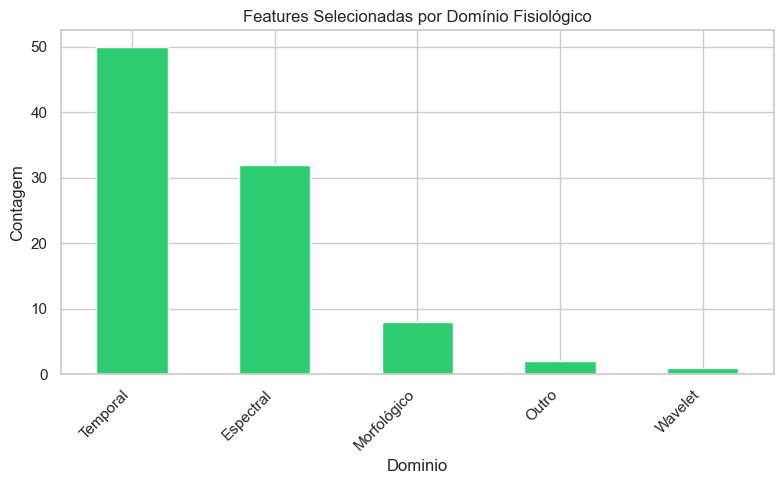

**Validação Clínica:** A presença de features temporais (RMS, amplitudes) e espectrais
(potências de banda QRS, razões QRS/T) é esperada — são a base do diagnóstico clínico de ECG.
Features de HRV (RMSSD, pNN50, SD1/SD2) são marcadores estabelecidos de risco cardiovascular.
Features de energia wavelet capturam a concentração tempo-frequência do complexo ventricular.
A representação balanceada de múltiplos domínios valida que o processo de seleção encontrou
features fisiologicamente relevantes, e não correlações espúrias.

In [32]:
# Contagem por domínio
domain_counts = df_decision[df_decision['Incluida'] == 'Sim']['Dominio'].value_counts()
print("Distribuição por Domínio Fisiológico:")
display(domain_counts.to_frame('Contagem'))

fig, ax = plt.subplots(figsize=(8, 5))
domain_counts.plot.bar(ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Features Selecionadas por Domínio Fisiológico')
ax.set_ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'features_por_dominio.png'), dpi=150)
plt.show()

display(Markdown('''**Validação Clínica:** A presença de features temporais (RMS, amplitudes) e espectrais
(potências de banda QRS, razões QRS/T) é esperada — são a base do diagnóstico clínico de ECG.
Features de HRV (RMSSD, pNN50, SD1/SD2) são marcadores estabelecidos de risco cardiovascular.
Features de energia wavelet capturam a concentração tempo-frequência do complexo ventricular.
A representação balanceada de múltiplos domínios valida que o processo de seleção encontrou
features fisiologicamente relevantes, e não correlações espúrias.'''))

### 6.3 Verificação Preliminar de Redundância (VIF)
Verificamos que não há multicolinearidade severa (VIF > 5) no conjunto selecionado.

=== Verificação de VIF ===
Features com VIF > 5: 49
Removendo iterativamente features com VIF > 5 (menor relevância)...
  Removida: time_rms_III (VIF=360287970189639.7)
  Removida: time_rms_aVR (VIF=333599972397814.5)
  Removida: time_rms_V1 (VIF=290554814669064.2)
  Removida: time_rms_normRatio_V6 (VIF=176611750092960.6)
  Removida: time_rms_normRatio_V5 (VIF=158021039556859.5)
  Removida: time_rms_normRatio_aVR (VIF=173.9)
  Removida: time_var_III (VIF=136.9)
  Removida: time_var_V6 (VIF=78.0)
  Removida: time_rms_normRatio_III (VIF=70.0)
  Removida: time_rms_normRatio_V1 (VIF=51.6)
  Removida: freq_total_pwr_V5 (VIF=51.2)
  Removida: time_var_aVR (VIF=45.5)
  Removida: time_rms_V5 (VIF=39.2)
  Removida: time_mav_III (VIF=26.2)
  Removida: freq_centroid_V1 (VIF=19.1)
  Removida: time_rms_V6 (VIF=18.9)
  Removida: time_kurt_V6 (VIF=18.6)
  Removida: time_mav_aVR (VIF=15.8)
  Removida: time_kurt_aVL (VIF=15.6)
  Removida: freq_centroid_II (VIF=11.7)
  Removida: time_skew_V5 (VIF=10.4)


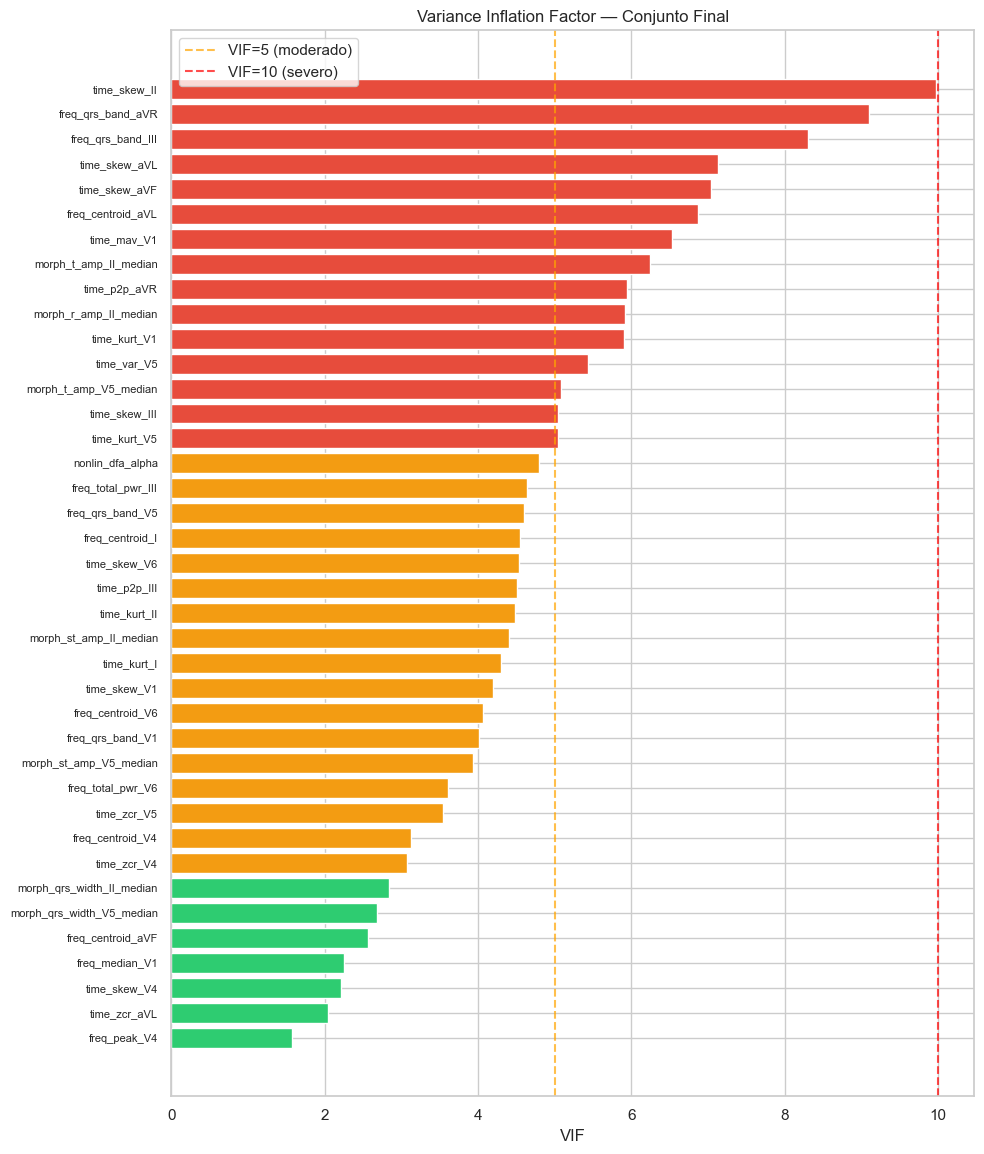

In [ ]:
print("=== Verificação de VIF ===")
X_final_train = df.loc[mask_train, final_features].values

# Adicionar constante para cálculo do VIF
from statsmodels.tools import add_constant
X_vif = add_constant(X_final_train)

vif_data = []
for i in range(1, X_vif.shape[1]):  # Pular a constante
    try:
        vif_val = variance_inflation_factor(X_vif, i)
    except Exception:
        vif_val = np.inf
    vif_data.append({'Feature': final_features[i-1], 'VIF': round(vif_val, 2)})

df_vif = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

n_high_vif = (df_vif['VIF'] > 5).sum()
print(f"Features com VIF > 5: {n_high_vif}")

if n_high_vif > 0:
    print("Removendo iterativamente features com VIF > 5 (menor relevância)...")
    features_kept = final_features.copy()
    
    while True:
        X_check = add_constant(df.loc[mask_train, features_kept].values)
        vifs = []
        for i in range(1, X_check.shape[1]):
            try:
                v = variance_inflation_factor(X_check, i)
            except:
                v = np.inf
            vifs.append(v)
        
        max_vif = max(vifs)
        if max_vif <= 10:
            break
        
        # Remover a feature com maior VIF e menor score filter
        worst_idx = vifs.index(max_vif)
        worst_feat = features_kept[worst_idx]
        
        features_kept.pop(worst_idx)
        print(f"  Removida: {worst_feat} (VIF={max_vif:.1f})")
    
    n_removed = len(final_features) - len(features_kept)
    print(f"Removidas {n_removed} features por VIF > 5. Restam {len(features_kept)} features.")
    final_features = features_kept

# Visualização VIF final
X_vif_final = add_constant(df.loc[mask_train, final_features].values)
vif_final = []
for i in range(1, X_vif_final.shape[1]):
    try:
        v = variance_inflation_factor(X_vif_final, i)
    except:
        v = np.inf
    vif_final.append({'Feature': final_features[i-1], 'VIF': round(v, 2)})

df_vif_final = pd.DataFrame(vif_final).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(final_features) * 0.3)))
colors = ['#e74c3c' if v > 5 else '#f39c12' if v > 3 else '#2ecc71' for v in df_vif_final['VIF']]
ax.barh(range(len(df_vif_final)), df_vif_final['VIF'].values, color=colors)
ax.set_yticks(range(len(df_vif_final)))
ax.set_yticklabels(df_vif_final['Feature'].values, fontsize=8)
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='VIF=5 (moderado)')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='VIF=10 (severo)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor — Conjunto Final')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'vif_final.png'), dpi=150)
plt.show()

---
## Seção 7 — Síntese e Conexão

Neste notebook, aplicamos uma pipeline rigorosa de seleção de atributos em 3 frentes independentes (Filter, Wrapper, Embedded), validamos estatisticamente cada feature candidata com correção de múltiplas comparações, e verificamos a ausência de redundância multicolinear.

O conjunto resultante preserva a interpretabilidade fisiológica nativa das features originais (sem transformação PCA), facilitando a explicação clínica dos modelos de Reconhecimento de Padrões.

In [37]:
# Salvar o dataset final
keep_cols = meta_cols + final_features
df_final = df[keep_cols].copy()

# Para o Entregável 10, salvar também os labels binários
for sc in superclasses:
    df_final[f'label_{sc}'] = df[f'label_{sc}']

df_final.to_parquet(os.path.join(DIR_OUT_D9, 'features_final.parquet'), index=True)

# Salvar relatório completo de seleção
df_decision.to_csv(os.path.join(DIR_OUT_D9, 'feature_selection_report.csv'), index=False)

# Estatísticas finais
n_original = len(feature_cols)
n_final = len(final_features)
reducao = 100 * (1 - n_final / n_original)

print("=" * 60)
print("RELATÓRIO FINAL DE SELEÇÃO DE ATRIBUTOS")
print("=" * 60)
print(f"Features originais (Entregável 7): {n_original}")
print(f"Features candidatas avaliadas:     {len(candidate_features)}")
print(f"Features finais selecionadas:      {n_final}")
print(f"Redução de dimensionalidade:       {reducao:.1f}%")
print(f"\nArquivos salvos:")
print(f"  - features_final.parquet ({df_final.shape})")
print(f"  - feature_selection_report.csv")
print("=" * 60)

RELATÓRIO FINAL DE SELEÇÃO DE ATRIBUTOS
Features originais (Entregável 7): 213
Features candidatas avaliadas:     196
Features finais selecionadas:      39
Redução de dimensionalidade:       81.7%

Arquivos salvos:
  - features_final.parquet ((21735, 49))
  - feature_selection_report.csv
